In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [157]:
df = pd.read_csv('co2.csv')
df
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   engine    500 non-null    float64
 1   cylandr   500 non-null    int64  
 2   fuelcomb  500 non-null    float64
 3   co2       500 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 15.8 KB


engine      0
cylandr     0
fuelcomb    0
co2         0
dtype: int64

In [158]:
for col in ['engine','fuelcomb','co2']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3*IQR
    upper = Q3 + 3*IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [159]:
df['cylandr_per_fuel'] = df['cylandr'] / (df['fuelcomb'] + 1)
df['engine_per_fuel'] = df['engine'] / (df['fuelcomb'] + 1)
df['engine_per_cylandr'] = df['engine'] / (df['cylandr'] + 1)


In [160]:
X = df.drop('co2',axis=1)
y = df['co2']

In [161]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [162]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [163]:
model = {
    "LinearRegression" : LinearRegression(),
    "lasso" : Lasso(alpha=0.1),
    "ridge" : Ridge(alpha=1.0),
    "random forest" : RandomForestRegressor(n_estimators=300,random_state=42,min_samples_leaf=4),
    "GradientBoosting" : GradientBoostingRegressor(n_estimators=300,random_state=42,min_samples_leaf=4),
}

In [164]:
Lr = model["LinearRegression"]
L1 = model["lasso"]
L2 = model["ridge"]
Rf = model["random forest"]
Gb = model["GradientBoosting"]

In [165]:
Lr.fit(X_train_scaled,y_train)
y_pred = Lr.predict(X_test_scaled)
Lr_accuracy = r2_score(y_test,y_pred)*100
Lr_mean_absolute_error = mean_absolute_error(y_test,y_pred)
Lr_mean_squared_error = mean_squared_error(y_test,y_pred)
Lr_accuracy

87.17885343325247

In [166]:
L1.fit(X_train_scaled,y_train)
y_pred = L1.predict(X_test_scaled)
L1_accuracy = r2_score(y_test,y_pred)*100
L1_mean_absolute_error = mean_absolute_error(y_test,y_pred)
L1_mean_squared_error = mean_squared_error(y_test,y_pred)
L1_accuracy


87.03847181187653

In [167]:
L2.fit(X_train_scaled,y_train)
y_pred = L2.predict(X_test_scaled)
L2_accuracy = r2_score(y_test,y_pred)*100
L2_mean_absolute_error = mean_absolute_error(y_test,y_pred)
L2_mean_squared_error = mean_squared_error(y_test,y_pred)
L2_accuracy

87.18806403193764

In [168]:
Rf.fit(X_train_scaled,y_train)
y_pred = Rf.predict(X_test_scaled)
Rf_accuracy = r2_score(y_test,y_pred)*100
Rf_mean_absolute_error = mean_absolute_error(y_test,y_pred)
Rf_mean_squared_error = mean_squared_error(y_test,y_pred)
Rf_accuracy

95.48725813385467

In [169]:
Gb.fit(X_train_scaled,y_train)
y_pred = Gb.predict(X_test_scaled)
Gb_accuracy = r2_score(y_test,y_pred)*100
Gb_mean_absolute_error = mean_absolute_error(y_test,y_pred)
Gb_mean_squared_error = mean_squared_error(y_test,y_pred)
Gb_accuracy

97.18851600482036

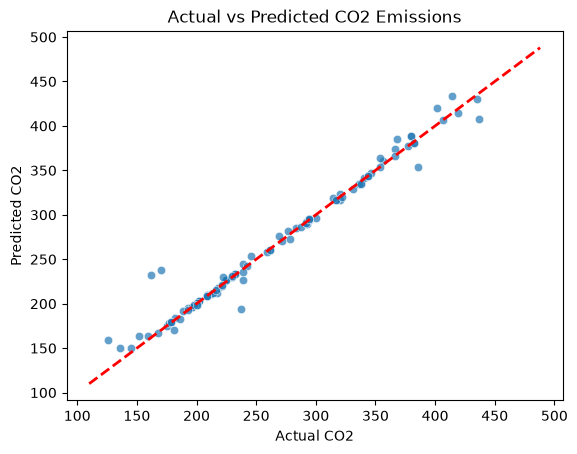

In [170]:
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual vs Predicted CO2 Emissions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2) # خط راهنمای 45 درجه
plt.show()

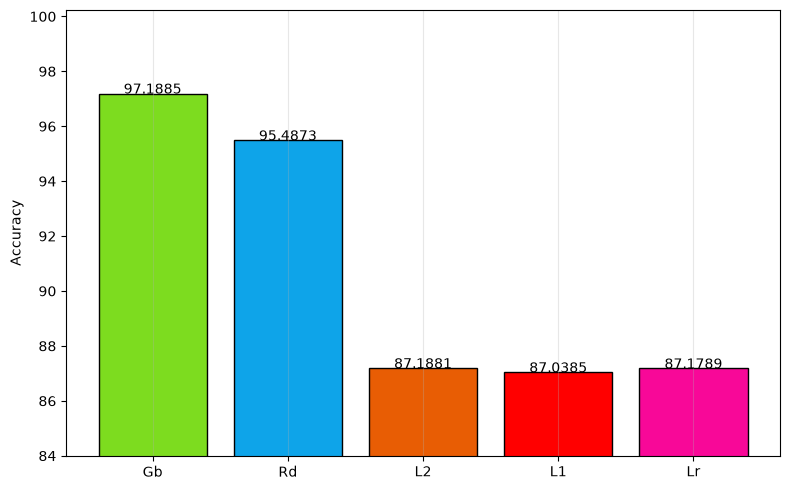

In [171]:
values = [Gb_accuracy, Rf_accuracy, L2_accuracy, L1_accuracy, Lr_accuracy]
labels = ["Gb", "Rd", "L2", "L1", "Lr"]
plt.figure(figsize=(8, 5))
colors = [
    "#7DDC1F",  
    "#0EA4E9",  
    "#E85D04",
    "#FF0000",
    "#F80898"]
bars = plt.bar(labels, values,color=colors, edgecolor="black", linewidth=1)


for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        values[i] + 0.0003,
        f"{values[i]:.4f}",
        ha="center",
        fontsize=10
    )


margin = (max(values) - min(values)) * 0.3
if margin == 0:
    margin = 0.001

plt.ylim(min(values) - margin, max(values) + margin)

plt.ylabel("Accuracy")
plt.grid(axis="x", linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()